# OpenAI compute Monte Carlo — cloud-spend version

This is an **alternate** estimate of OpenAI's 2024 and 2025 compute, built from
**reported cloud compute spend** rather than from the disclosed power figures.
The power-based notebook (`openai_power_model.py`) is the canonical
model; this one asks what the same fleet looks like if we instead trust the
dollar figures — **~\$6.8B in 2024** (amortization-adjusted) and **\$16.3B in
2025** — and convert dollars to H100-equivalents at contract rental rates.

It replaces the archived `archive/gpu_hour_model.ipynb`, which did this as a
point-estimate scenario grid: fixed prices, a Hopper/Blackwell mix taken from
*world* cumulative chip stock, and no uncertainty.

The model is **incremental, like the power model**. OpenAI buys its compute on
long-term (multi-year) contracts, so capacity added in a given year keeps both
the chip mix it was deployed with *and the price it was signed at* — the fleet
never reprices onto newer, cheaper deals. Concretely:

1. The annual spend totals pin a **spending run-rate curve** (section 2); its
   year-end values are the annualized contract commitments at each date.
2. Each year's **increase** in the run-rate is new contracts, priced at that
   **vintage's** contract rates and buying that vintage's chip mix (the power
   model's year-over-year fleet additions).
3. Vintages accumulate — end-2025 = pre-2024 legacy + 2024 additions + 2025
   additions, each layer at its own locked price.

The vintage structure is what smooths the price story: Hopper contract rates
signed in 2024 vs 2025 are separate (overlapping) distributions, and the
fleet's blended price falls gradually as cheaper vintages stack on top of
older ones, rather than the whole fleet jumping between two price regimes.

Annual totals give **year-end snapshots** as the primary output (the
apples-to-apples comparison with the power model), plus **full-year averages**
as a byproduct of the same run-rate curve. Priors are notebook literals, not
`lab_model_params.csv` rows — like the Anthropic cloud-spend notebook, this is
a cross-check kept out of the canonical sheet.

In [1]:
import contextlib
import io
import runpy
import sys
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import squigglepy as sq

# Shared modules (lab_compute_utils, epoch_data) live at the repo root, one
# level up from notebooks/.
sys.path.insert(0, str(Path('..').resolve()))

N_SAMPLES = 5000
sq.set_seed(42)  # squigglepy has its own RNG; np.random.seed does not affect it

HOURS_PER_YEAR = 8760  # continuous rental implied, as in the Anthropic spend model
YEARS = [2024, 2025]
BUCKETS = ['A100', 'Hopper', 'Blackwell']
VINTAGES = ['pre-2024', '2024', '2025']
BUCKET_COLORS = {'A100': '#8b5cf6', 'Hopper': '#76b900', 'Blackwell': '#1a73e8'}
# The vintages are one family (layers of the same fleet), so they share a hue
# as a light-to-dark ramp.
VINTAGE_COLORS = {'pre-2024': '#a5c8ac', '2024': '#4f9e63', '2025': '#0d5c26'}
SPEND_COLOR, SPEND_DARK = '#188038', '#0d5c26'   # this model
POWER_COLOR = '#1a73e8'                          # the canonical power model


def fmt(value):
    """Format an H100e or chip count as a short string (millions or thousands)."""
    if abs(value) >= 1e6:
        return f'{value / 1e6:.2f}M'
    return f'{value / 1e3:,.0f}k'


def percentiles(samples):
    """Return (5th, 50th, 95th) percentiles of a sample array."""
    p = sq.get_percentiles(samples, percentiles=[5, 50, 95])
    return p[5], p[50], p[95]

## 1. Borrow the fleet mix and chip specs from the power model

We run the canonical power notebook once (quietly) and read out three things:

- **Per-chip H100e** for each Nvidia part.
- **The chip-count additions per vintage** (median across its Monte Carlo):
  the end-2023 fleet is the pre-2024 legacy layer, and the year-over-year
  count deltas are what the 2024 and 2025 contract vintages bought. B200 and
  GB300 fold into one Blackwell bucket; the A100 stays its own bucket because
  it dominates the legacy layer and rents much cheaper than Hopper.
- The power model's **year-end H100e distributions**, kept for the section 6
  comparison.

Using the power model's additions to split each vintage's *dollars* is the
main upgrade over the archived model: the split reflects what OpenAI actually
racked each year, not what the world bought. It does make the two models less
than fully independent — but only through the mix, which barely moves the
headline (contract prices roughly track H100e across chip generations, so
H100e-per-dollar is insensitive to the split). The *level* here comes entirely
from dollars and prices, not from power.

In [2]:
def load_openai_namespace():
    """Execute the OpenAI power notebook script and hand back its variables,
    without letting its own prints or charts render here."""
    oai_path = 'openai_power_model.py'
    original_show = plt.show
    plt.show = lambda *args, **kwargs: None  # swallow the power model's figures
    try:
        with contextlib.redirect_stdout(io.StringIO()), warnings.catch_warnings():
            warnings.simplefilter('ignore')
            namespace = runpy.run_path(oai_path)
    finally:
        plt.show = original_show
        plt.close('all')
    return namespace


openai = load_openai_namespace()
date_of_year = {d.year: d for d in openai['OPENAI_DATES']}
oai_h100e = openai['h100e_per_gpu']

# The power model's year-end totals (full sample arrays), for section 6.
power_h100e = {yr: openai['mc'][date_of_year[yr]]['total_h100e'] for yr in YEARS}

# Median chip counts per bucket at each year-end, folded to A100 / Hopper /
# Blackwell (keeping the B200/B300 detail for the Blackwell H100e blend).
counts_by_year = {}
for yr in [2023, 2024, 2025]:
    counts = openai['mc'][date_of_year[yr]]['counts']
    counts_by_year[yr] = {
        'A100': float(np.median(counts['A100'])),
        'Hopper': float(np.median(counts['H100/H200'])),
        'B200': float(np.median(counts['B200'])),
        'B300': float(np.median(counts['B300'])),
    }


def vintage_mix_and_specs(added_counts):
    """Normalize a dict of added chip counts into bucket count shares plus
    per-chip H100e per bucket (Blackwell = count-weighted B200/B300 blend)."""
    folded = {
        'A100': max(added_counts['A100'], 0.0),
        'Hopper': max(added_counts['Hopper'], 0.0),
        'Blackwell': max(added_counts['B200'], 0.0) + max(added_counts['B300'], 0.0),
    }
    total = sum(folded.values())
    mix = {b: folded[b] / total for b in BUCKETS}
    blackwell_h100e = (
        (max(added_counts['B200'], 0.0) * oai_h100e['B200']
         + max(added_counts['B300'], 0.0) * oai_h100e['B300']) / folded['Blackwell']
        if folded['Blackwell'] > 0 else oai_h100e['B200'])
    specs = {'A100': oai_h100e['A100'], 'Hopper': oai_h100e['H100/H200'],
             'Blackwell': blackwell_h100e}
    return mix, specs


# Pre-2024 legacy layer = the end-2023 fleet; the 2024 and 2025 vintages are
# the year-over-year additions.
added_counts = {
    'pre-2024': counts_by_year[2023],
    '2024': {c: counts_by_year[2024][c] - counts_by_year[2023][c] for c in counts_by_year[2023]},
    '2025': {c: counts_by_year[2025][c] - counts_by_year[2024][c] for c in counts_by_year[2023]},
}
count_mix, bucket_h100e = {}, {}
for vintage in VINTAGES:
    count_mix[vintage], bucket_h100e[vintage] = vintage_mix_and_specs(added_counts[vintage])

print('Chip-count mix bought by each contract vintage (power-model medians):')
for vintage in VINTAGES:
    shares = ', '.join(f'{b} {count_mix[vintage][b]:.0%}' for b in BUCKETS
                       if count_mix[vintage][b] > 0.005)
    print(f'   {vintage:9s}: {shares}')

Chip-count mix bought by each contract vintage (power-model medians):
   pre-2024 : A100 62%, Hopper 38%
   2024     : A100 1%, Hopper 99%
   2025     : Hopper 40%, Blackwell 60%


## 2. The spend anchors and the run-rate curve

Both spend figures come from The Information's reporting on OpenAI's
financials:

- **2024: \$5.8B reported, treated as ~\$6.8B here.** The reported figure is
  post-amortization — about \$1B of prepaid research compute was amortized
  rather than expensed — so the cash-basis proxy for *compute actually used*
  in 2024 is roughly \$6.8B. Sampled as a lognormal, 90% CI \$6.0–7.7B.
- **2025: \$16.3B.** Sampled with the same relative width, 90% CI \$14.5–18.3B.

The two are **correlated (0.5)**: they come from the same reporting stream and
accounting definitions, so errors tend to point the same way.

The incremental model needs the **run-rate** (annualized contract commitments)
at each year-end, recovered the same way as in the Anthropic spend notebooks:

- If the run-rate grows exponentially through 2025, the ratio of the two
  annual totals *is* the average growth, and a **growth-shape factor** (90% CI
  0.6–1.6) scales the within-2025 rate around that average — below 1
  front-loaded, above 1 back-loaded. Two annual totals can't say *when* within
  the year the money arrived, and (unlike the Anthropic backcast) no quarterly
  spend build exists here to narrow the prior, so it stays diffuse. That pins
  the **end-2025** rate, and the **end-2024** rate is where the 2025
  exponential starts.
- Within 2024 no extra assumption is needed: the segment must end at the
  end-2024 rate *and* integrate to the 2024 total, which pins its growth rate
  per sample (solved by bisection). Where that curve starts is the
  **end-2023** rate — the legacy layer's commitments.

In [3]:
spend_2024_dist, spend_2025_dist = sq.correlate((sq.to(6.0, 7.7), sq.to(14.5, 18.3)), 0.5)
spend_total = {
    2024: (spend_2024_dist @ N_SAMPLES) * 1e9,
    2025: (spend_2025_dist @ N_SAMPLES) * 1e9,
}
growth_shape = sq.to(0.6, 1.6) @ N_SAMPLES

print('Full-year cloud compute spend ($B), 5th / median / 95th:')
for yr in YEARS:
    lo, mid, hi = percentiles(spend_total[yr])
    print(f'   {yr}: {lo / 1e9:.1f} / {mid / 1e9:.1f} / {hi / 1e9:.1f}')

Full-year cloud compute spend ($B), 5th / median / 95th:
   2024: 6.0 / 6.8 / 7.7
   2025: 14.5 / 16.3 / 18.3


In [4]:
def solve_within_year_growth(total, end_rate):
    """Growth rate of an exponential run-rate that ends the year at end_rate
    while integrating to the year's total. Vectorized bisection on
    (1 - exp(-g))/g = total/end_rate, which falls monotonically in g."""
    target = total / end_rate
    lo = np.full_like(target, -10.0)
    hi = np.full_like(target, 20.0)
    for _ in range(80):
        mid = (lo + hi) / 2
        fraction = np.where(np.abs(mid) < 1e-9, 1 - mid / 2, (1 - np.exp(-mid)) / mid)
        too_flat = fraction > target  # integral still too large -> need faster growth
        lo = np.where(too_flat, mid, lo)
        hi = np.where(too_flat, hi, mid)
    return (lo + hi) / 2


def spend_runrates(spend_24, spend_25, shape):
    """Year-end annualized run-rates implied by the two totals and the
    within-2025 growth shape. Returns rates at end-2023/24/25 plus the two
    within-year growth rates."""
    # Within-2025 growth = average 2024->2025 growth x the shape factor; the
    # 2025 exponential then integrates to the 2025 total.
    growth_2025 = np.log(spend_25 / spend_24) * shape
    rate_end_2025 = spend_25 * growth_2025 / (1 - np.exp(-growth_2025))
    rate_end_2024 = rate_end_2025 * np.exp(-growth_2025)
    # Within-2024 growth is pinned by the 2024 total and the boundary rate.
    growth_2024 = solve_within_year_growth(spend_24, rate_end_2024)
    rate_end_2023 = rate_end_2024 * np.exp(-growth_2024)
    return {'end_2023': rate_end_2023, 'end_2024': rate_end_2024,
            'end_2025': rate_end_2025, 'growth_2024': growth_2024,
            'growth_2025': growth_2025}


rates = spend_runrates(spend_total[2024], spend_total[2025], growth_shape)

print('Spending run-rates (5th / median / 95th):')
for key, label in [('end_2023', 'end-2023 rate ($B/yr)'),
                   ('end_2024', 'end-2024 rate ($B/yr)'),
                   ('end_2025', 'end-2025 rate ($B/yr)')]:
    lo, mid, hi = percentiles(rates[key])
    print(f'   {label}:   {lo / 1e9:.1f} / {mid / 1e9:.1f} / {hi / 1e9:.1f}')
for key, label in [('growth_2024', 'within-2024'), ('growth_2025', 'within-2025')]:
    lo, mid, hi = percentiles(np.exp(rates[key]))
    print(f'   {label} growth factor: {lo:.1f}x / {mid:.1f}x / {hi:.1f}x')
print('   (the disclosed power trajectory grew ~3.0x during 2024 and ~3.2x during 2025)')

Spending run-rates (5th / median / 95th):
   end-2023 rate ($B/yr):   3.0 / 4.3 / 6.4
   end-2024 rate ($B/yr):   7.4 / 10.2 / 12.8
   end-2025 rate ($B/yr):   19.7 / 24.3 / 31.5
   within-2024 growth factor: 1.2x / 2.4x / 4.0x
   within-2025 growth factor: 1.7x / 2.4x / 4.1x
   (the disclosed power trajectory grew ~3.0x during 2024 and ~3.2x during 2025)


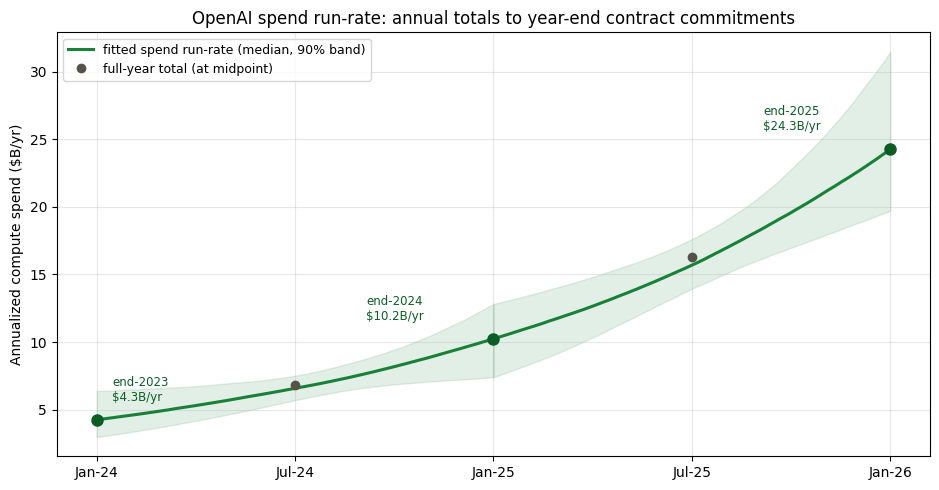

In [5]:
# The fitted run-rate curve: pointwise medians of the per-sample exponential
# segments, which meet at the year boundary by construction.
u = np.linspace(0, 1, 101)
paths_2024 = rates['end_2023'][:, None] * np.exp(np.outer(rates['growth_2024'], u))
paths_2025 = rates['end_2024'][:, None] * np.exp(np.outer(rates['growth_2025'], u))

fig, ax = plt.subplots(figsize=(9.5, 5))
for paths, x0 in [(paths_2024, 2024), (paths_2025, 2025)]:
    ax.fill_between(x0 + u, np.percentile(paths, 5, axis=0) / 1e9,
                    np.percentile(paths, 95, axis=0) / 1e9, color=SPEND_COLOR, alpha=0.12)
    ax.plot(x0 + u, np.median(paths, axis=0) / 1e9, color=SPEND_COLOR, lw=2.2)
ax.plot([], [], color=SPEND_COLOR, lw=2.2, label='fitted spend run-rate (median, 90% band)')

# The three year-end rates the vintage layers are cut at.
for x, samples, label, dx in [(2024.0, rates['end_2023'], 'end-2023', 0.04),
                              (2025.0, rates['end_2024'], 'end-2024', -0.32),
                              (2026.0, rates['end_2025'], 'end-2025', -0.32)]:
    mid = float(np.median(samples))
    ax.plot(x, mid / 1e9, 'o', color=SPEND_DARK, markersize=8, zorder=5)
    ax.annotate(f'{label}\n${mid / 1e9:.1f}B/yr', xy=(x, mid / 1e9),
                xytext=(x + dx, mid / 1e9 + 1.4), fontsize=8.5, color=SPEND_DARK)
ax.plot([2024.5, 2025.5],
        [np.median(spend_total[2024]) / 1e9, np.median(spend_total[2025]) / 1e9],
        'o', color='#555349', markersize=6, ls='none',
        label='full-year total (at midpoint)')

ax.set_xticks([2024, 2024.5, 2025, 2025.5, 2026])
ax.set_xticklabels(['Jan-24', 'Jul-24', 'Jan-25', 'Jul-25', 'Jan-26'])
ax.set_ylabel('Annualized compute spend ($B/yr)')
ax.set_title('OpenAI spend run-rate: annual totals to year-end contract commitments',
             fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Vintage pricing

**Contract rates (\$/GPU-hour) per vintage.** Each vintage's price is what
multi-year contracts signed in that period cost — and it stays locked for the
life of the layer. The 90% CIs:

| Vintage | A100 | Hopper | Blackwell | Reasoning |
|---|---|---|---|---|
| pre-2024 | 1.20–2.00 | 1.75–2.50 | — | 1-yr H100 contracts ran ~\$3/hr through 2023 (SemiAnalysis index), and multi-year terms price well under that; A100 terms date from 2022–23, when The Information reported deeply discounted Azure A100 rates for OpenAI |
| 2024 | — | 1.50–2.25 | — | the 1-yr index fell to the low-\$2s through 2024; 3–5-yr terms sit below it |
| 2025 | — | 1.20–1.80 | 3.00–4.00 | anchored on SemiAnalysis's Aug-2025 3-yr-contract survey (H100 \$1.30, H200 \$1.60), widened both ways; Blackwell spans that survey (B200 \$2.90, GB200 \$3.30) up toward the Silicon Data spot index |

(The 2024 vintage bought essentially no A100 or Blackwell, so those cells
reuse the neighboring draws for the ~0% slices.) All five prices are
**correlated (0.7)** — they ride one rental market, so a high-price world
lifts every vintage together. The overlap between the 2024 and 2025 Hopper
CIs is deliberate: these are separate signings in a falling but noisy market.

**Effective-rate factor.** OpenAI does not pay list contract rates, and its
reported "compute spend" is not purely GPU-hours. One shared multiplier on all
prices covers both, 90% CI **0.85–1.25**:

- *Below 1:* OpenAI's scale, multi-year commitments, and the Microsoft
  relationship buy rates below market.
- *Above 1:* the reported spend plausibly includes storage, networking, CPU
  fleets, and other auxiliary costs beyond raw GPU-hours, making the effective
  dollars-per-GPU-hour higher than the sticker rate.

The slight upward lean (median ~1.03) reflects the research summary's
reconciliation: the naive spend conversion runs above the power model,
suggesting the auxiliary-cost effect somewhat outweighs the discounts.

In [6]:
price_dists = sq.correlate((
    sq.to(1.20, 2.00),   # A100, pre-2024 contracts
    sq.to(1.75, 2.50),   # Hopper, pre-2024 contracts
    sq.to(1.50, 2.25),   # Hopper, 2024 contracts
    sq.to(1.20, 1.80),   # Hopper, 2025 contracts
    sq.to(3.00, 4.00),   # Blackwell, 2025 contracts
), 0.7)
a100_legacy, hopper_legacy, hopper_24, hopper_25, blackwell_25 = (
    d @ N_SAMPLES for d in price_dists)

# One shared draw: discounts below market vs auxiliary costs above, all vintages.
effective_rate_factor = sq.to(0.85, 1.25) @ N_SAMPLES

# Market price per vintage and bucket; the ~0% slices reuse neighboring draws.
market_price = {
    'pre-2024': {'A100': a100_legacy, 'Hopper': hopper_legacy, 'Blackwell': blackwell_25},
    '2024': {'A100': a100_legacy, 'Hopper': hopper_24, 'Blackwell': blackwell_25},
    '2025': {'A100': a100_legacy, 'Hopper': hopper_25, 'Blackwell': blackwell_25},
}
effective_price = {
    v: {b: market_price[v][b] * effective_rate_factor for b in BUCKETS} for v in VINTAGES
}

print('Effective contract prices to OpenAI ($/GPU-hour), 5th / median / 95th:')
for vintage in VINTAGES:
    for bucket in BUCKETS:
        if count_mix[vintage][bucket] < 0.005:
            continue  # ~0% of this vintage
        lo, mid, hi = percentiles(effective_price[vintage][bucket])
        print(f'   {bucket:10s} {vintage:9s}: {lo:.2f} / {mid:.2f} / {hi:.2f}')
lo, mid, hi = percentiles(effective_rate_factor)
print(f'   effective-rate factor: {lo:.2f} / {mid:.2f} / {hi:.2f}')

Effective contract prices to OpenAI ($/GPU-hour), 5th / median / 95th:
   A100       pre-2024 : 1.16 / 1.60 / 2.20
   Hopper     pre-2024 : 1.66 / 2.15 / 2.80
   A100       2024     : 1.16 / 1.60 / 2.20
   Hopper     2024     : 1.42 / 1.89 / 2.51
   Hopper     2025     : 1.14 / 1.51 / 2.00
   Blackwell  2025     : 2.80 / 3.57 / 4.58
   effective-rate factor: 0.85 / 1.03 / 1.25


### What a dollar buys in each vintage

H100e bought per dollar of annual commitment is the per-chip H100e divided by
a year of rental (`price × 8760`). Blackwell rents at roughly its H100e
premium, so dollar-efficiency is similar across Hopper and Blackwell vintages
— which is why the mix barely moves the headline. The legacy A100 layer is the
clear loser: cheap rent, but little compute per dollar.

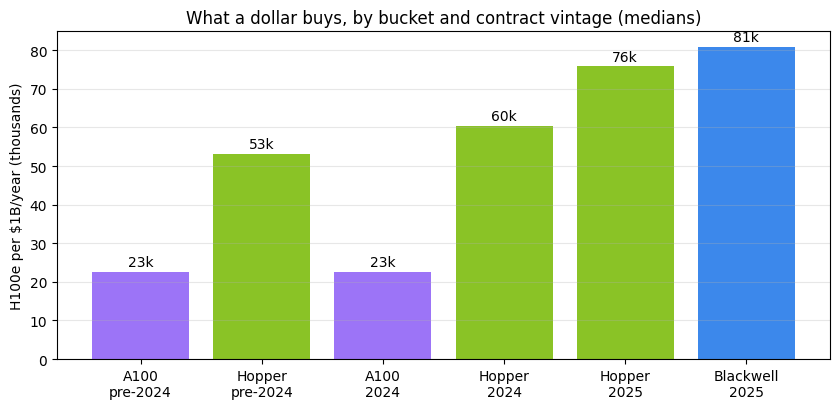

In [7]:
def h100e_per_dollar_year(per_chip_h100e, price_per_hour):
    """H100e bought per $1 of annual spend on a chip rented all year."""
    return per_chip_h100e / (price_per_hour * HOURS_PER_YEAR)


fig, ax = plt.subplots(figsize=(8.5, 4.2))
labels, values, colors = [], [], []
for vintage in VINTAGES:
    for bucket in BUCKETS:
        if count_mix[vintage][bucket] < 0.005:
            continue
        per_b = h100e_per_dollar_year(
            bucket_h100e[vintage][bucket], effective_price[vintage][bucket]) * 1e9
        labels.append(f'{bucket}\n{vintage}')
        values.append(float(np.median(per_b)) / 1e3)
        colors.append(BUCKET_COLORS[bucket])
ax.bar(labels, values, color=colors, alpha=0.85)
for col, value in enumerate(values):
    ax.text(col, value + 1.5, f'{value:,.0f}k', ha='center', fontsize=10)
ax.set_ylabel('H100e per $1B/year (thousands)')
ax.set_title('What a dollar buys, by bucket and contract vintage (medians)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 4. The incremental model

Each vintage's dollars are the run-rate *increment* across its year (the
legacy layer gets the whole end-2023 rate). Within a vintage, the dollars
split across buckets so the resulting chip counts keep that vintage's count
mix — given the mix and the prices, the dollar split is pinned (a bucket's
dollar share is its count share times its hourly price, renormalized). Each
slice then converts dollars to chips (`dollars ÷ price ÷ 8760`) and on to
H100e, and the layers stack:

- **end-2024 fleet** = pre-2024 layer + 2024 additions
- **end-2025 fleet** = end-2024 fleet + 2025 additions

Because contracts never reprice, a layer built once never changes — exactly
the vintage-layered structure of the power model, with dollars in place of
megawatts. Increments are floored at zero (contracts don't uncommit); the
floor only binds in extreme tail samples where the fitted 2024 curve slopes
down.

In [8]:
def vintage_fleet(dollars, vintage, prices):
    """Chips and H100e bought by one vintage's annualized dollars ($/yr array)
    at that vintage's contract prices and count mix."""
    mix = count_mix[vintage]
    # A bucket's share of the dollars is its count share times its hourly price;
    # dividing spend by price and hours then lands the chips back on the mix.
    dollars_per_mix_chip = sum(mix[b] * prices[vintage][b] for b in BUCKETS)
    chips = {b: dollars * mix[b] / dollars_per_mix_chip / HOURS_PER_YEAR for b in BUCKETS}
    h100e = {b: chips[b] * bucket_h100e[vintage][b] for b in BUCKETS}
    return {
        'chips': chips,
        'h100e': h100e,
        'total_chips': sum(chips.values()),
        'total_h100e': sum(h100e.values()),
    }


def run_model(spend_24, spend_25, shape, prices):
    """The full pipeline: totals -> run-rates -> vintage layers -> year-end
    snapshots and full-year averages. Every argument is sampled or held at its
    median; prices is a {vintage: {bucket: array}} dict of effective rates."""
    r = spend_runrates(spend_24, spend_25, shape)

    # Dollars per vintage: the legacy layer carries the whole end-2023 rate;
    # each later vintage is its year's increment in the run-rate.
    vintage_dollars = {
        'pre-2024': r['end_2023'],
        '2024': np.maximum(r['end_2024'] - r['end_2023'], 0.0),
        '2025': np.maximum(r['end_2025'] - r['end_2024'], 0.0),
    }
    layers = {v: vintage_fleet(vintage_dollars[v], v, prices) for v in VINTAGES}

    snapshot = {
        2024: layers['pre-2024']['total_h100e'] + layers['2024']['total_h100e'],
        2025: (layers['pre-2024']['total_h100e'] + layers['2024']['total_h100e']
               + layers['2025']['total_h100e']),
    }

    # Full-year averages fall out of the same curve: the fleet during a year is
    # the carried-over layers plus additions-to-date, and averaging the additions
    # over the year turns the run-rate into the year's total spend minus the
    # starting rate. (The average of an annualized rate over one year IS the
    # annual total.)
    average = {
        2024: (layers['pre-2024']['total_h100e']
               + vintage_fleet(np.maximum(spend_24 - r['end_2023'], 0.0),
                               '2024', prices)['total_h100e']),
        2025: (snapshot[2024]
               + vintage_fleet(np.maximum(spend_25 - r['end_2024'], 0.0),
                               '2025', prices)['total_h100e']),
    }
    return {'rates': r, 'layers': layers, 'snapshot': snapshot, 'average': average}


result = run_model(spend_total[2024], spend_total[2025], growth_shape, effective_price)

print('Year-end snapshot H100e (5th / median / 95th):')
for yr in YEARS:
    lo, mid, hi = percentiles(result['snapshot'][yr])
    print(f'   end-{yr}: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')
print('\nMedian H100e by contract vintage (end-2025 fleet):')
for vintage in VINTAGES:
    layer = result['layers'][vintage]
    parts = ', '.join(f'{b} {fmt(np.median(layer["h100e"][b]))}' for b in BUCKETS
                      if count_mix[vintage][b] > 0.005)
    print(f'   {vintage:9s}: {fmt(np.median(layer["total_h100e"]))}   ({parts})')

Year-end snapshot H100e (5th / median / 95th):
   end-2024: 297k / 506k / 773k
   end-2025: 1.14M / 1.64M / 2.41M

Median H100e by contract vintage (end-2025 fleet):
   pre-2024 : 154k   (A100 53k, Hopper 101k)
   2024     : 354k   (A100 1k, Hopper 351k)
   2025     : 1.10M   (Hopper 233k, Blackwell 870k)


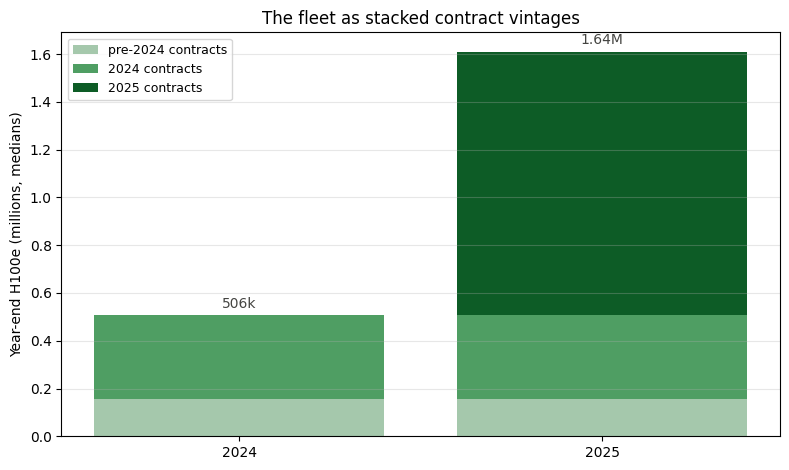

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.8))
bottom = np.zeros(len(YEARS))
included = {2024: ['pre-2024', '2024'], 2025: VINTAGES}
for vintage in VINTAGES:
    heights = [np.median(result['layers'][vintage]['total_h100e']) / 1e6
               if vintage in included[yr] else 0.0 for yr in YEARS]
    ax.bar([str(y) for y in YEARS], heights, bottom=bottom,
           color=VINTAGE_COLORS[vintage], label=f'{vintage} contracts')
    bottom += np.array(heights)
for x, yr in enumerate(YEARS):
    ax.text(x, bottom[x] + 0.03, fmt(np.median(result['snapshot'][yr])),
            ha='center', fontsize=10, color='#444441')
ax.set_ylabel('Year-end H100e (millions, medians)')
ax.set_title('The fleet as stacked contract vintages', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 5. Full-year averages

The same run-rate curve also gives the **full-year average** fleet — the
carried-in layers plus the year's additions averaged over when they arrived.
These are the numbers to compare against annual-total intuitions (spend ÷
average price), and they sit well below the year-end snapshots because both
years back-loaded their growth.

In [10]:
print('Full-year average H100e (5th / median / 95th):')
for yr in YEARS:
    lo, mid, hi = percentiles(result['average'][yr])
    ratio = np.median(result['snapshot'][yr]) / np.median(result['average'][yr])
    print(f'   {yr}: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}   (year-end snapshot {ratio:.2f}x higher)')

Full-year average H100e (5th / median / 95th):
   2024: 223k / 304k / 417k   (year-end snapshot 1.66x higher)
   2025: 747k / 993k / 1.33M   (year-end snapshot 1.65x higher)


## 6. Comparison with the power model

The **snapshots** are the like-for-like comparison: the power model's outputs
are year-end fleets. The research summary's reconciliation expected the spend
conversion to run ~0–40% above the power model, with the 2024 gap larger —
reported "compute spend" likely covers more than raw GPU-hours, and the
effective-rate factor only partly absorbs that. The comparison below puts
numbers on it.

In [11]:
print(f'{"":8s}{"spend avg":>22s}{"spend snapshot":>26s}{"power model (year-end)":>28s}')
for yr in YEARS:
    cells = []
    for samples in (result['average'][yr], result['snapshot'][yr], power_h100e[yr]):
        lo, mid, hi = percentiles(samples)
        cells.append(f'{fmt(lo)} /{fmt(mid)} /{fmt(hi)}')
    print(f'   {yr}: {cells[0]:>22s}   {cells[1]:>26s}   {cells[2]:>26s}')

for yr in YEARS:
    gap = np.median(result['snapshot'][yr]) / np.median(power_h100e[yr])
    print(f'   end-{yr} snapshot / power model (medians): {gap:.2f}x')

                     spend avg            spend snapshot      power model (year-end)
   2024:       223k /304k /417k             297k /506k /773k             276k /384k /485k
   2025:      747k /993k /1.33M          1.14M /1.64M /2.41M          1.24M /1.74M /2.17M
   end-2024 snapshot / power model (medians): 1.32x
   end-2025 snapshot / power model (medians): 0.94x


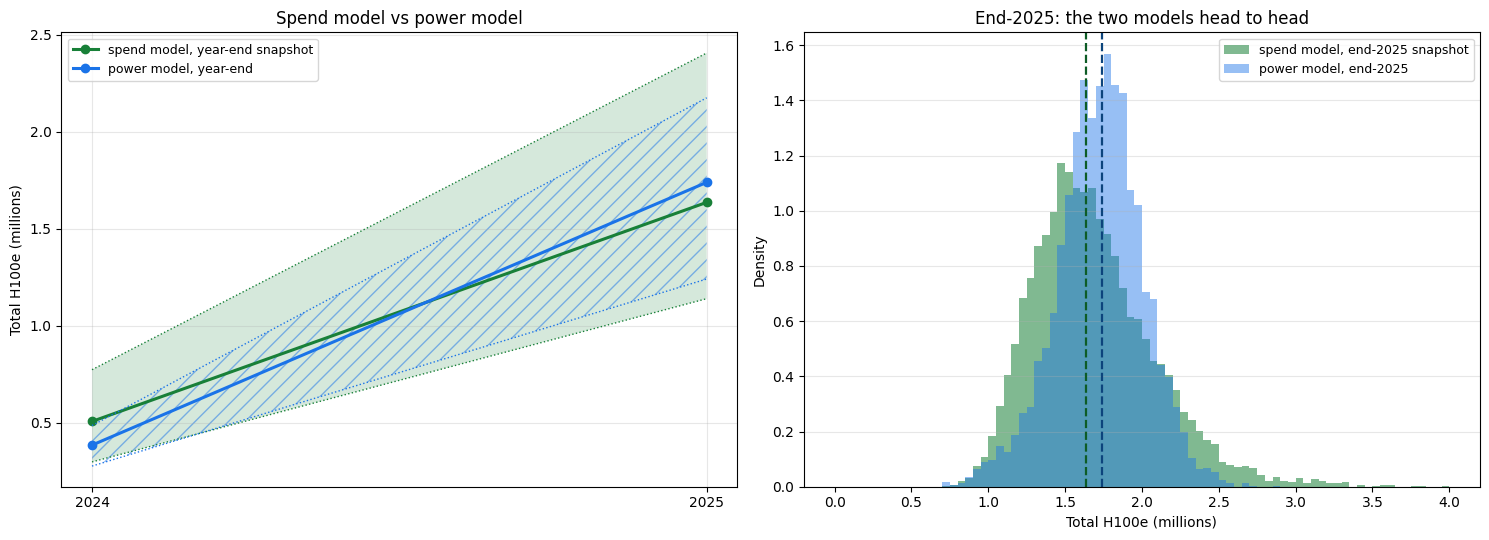

In [12]:
fig, (ax_years, ax_hist) = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: the two year-end snapshot series, medians with 90% intervals. The
# overlapping bands get different textures: solid fill for the spend model,
# hatching for the power model, each edged in its own color.
series = [
    ('spend model, year-end snapshot', [result['snapshot'][yr] for yr in YEARS],
     SPEND_COLOR, dict(facecolor=SPEND_COLOR, alpha=0.18)),
    ('power model, year-end', [power_h100e[yr] for yr in YEARS],
     POWER_COLOR, dict(facecolor='none', hatch='//', edgecolor=POWER_COLOR, alpha=0.5)),
]
for label, samples_by_year, color, band_style in series:
    lows, mids, highs = zip(*[percentiles(s) for s in samples_by_year])
    ax_years.fill_between(YEARS, np.array(lows) / 1e6, np.array(highs) / 1e6,
                          linewidth=0, **band_style)
    for edge in (lows, highs):
        ax_years.plot(YEARS, np.array(edge) / 1e6, color=color, lw=1.0, ls=':')
    ax_years.plot(YEARS, np.array(mids) / 1e6, color=color, lw=2.2,
                  marker='o', label=label)
ax_years.set_title('Spend model vs power model', fontsize=12)
ax_years.set_ylabel('Total H100e (millions)')
ax_years.set_xticks(YEARS)
ax_years.legend(loc='upper left', fontsize=9)
ax_years.grid(True, alpha=0.3)

# Right: end-2025 snapshot vs the power model's end-2025 distribution.
bins = np.linspace(0, 4, 81)
ax_hist.hist(result['snapshot'][2025] / 1e6, bins=bins, density=True, alpha=0.55,
             color=SPEND_COLOR, label='spend model, end-2025 snapshot')
ax_hist.hist(power_h100e[2025] / 1e6, bins=bins, density=True, alpha=0.45,
             color=POWER_COLOR, label='power model, end-2025')
for samples, color in [(result['snapshot'][2025], SPEND_DARK),
                       (power_h100e[2025], '#0c447c')]:
    ax_hist.axvline(np.median(samples) / 1e6, color=color, lw=1.6, ls='--')
ax_hist.set_title('End-2025: the two models head to head', fontsize=12)
ax_hist.set_xlabel('Total H100e (millions)')
ax_hist.set_ylabel('Density')
ax_hist.legend(fontsize=9)
ax_hist.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. What drives the uncertainty

For the end-2025 snapshot, turn each random input on alone (the others held at
their medians): the spend totals, the prices (including the effective-rate
factor), and the growth shape. The growth shape matters only for the
average-to-snapshot step, but that step is the least constrained — two annual
totals say nothing about within-year timing.

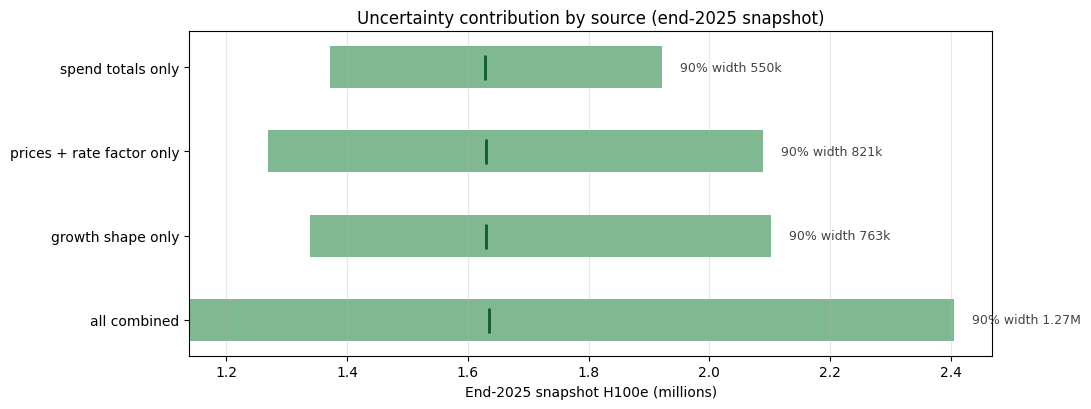

End-2025 snapshot H100e by source (5th / median / 95th):
   spend totals only           : 1.37M / 1.63M / 1.92M
   prices + rate factor only   : 1.27M / 1.63M / 2.09M
   growth shape only           : 1.34M / 1.63M / 2.10M
   all combined                : 1.14M / 1.64M / 2.41M


In [13]:
s24_med = np.full(N_SAMPLES, np.median(spend_total[2024]))
s25_med = np.full(N_SAMPLES, np.median(spend_total[2025]))
shape_med = np.full(N_SAMPLES, np.median(growth_shape))
prices_med = {v: {b: float(np.median(effective_price[v][b])) for b in BUCKETS}
              for v in VINTAGES}

decomposition = {
    'spend totals only': run_model(spend_total[2024], spend_total[2025],
                                   shape_med, prices_med),
    'prices + rate factor only': run_model(s24_med, s25_med, shape_med, effective_price),
    'growth shape only': run_model(s24_med, s25_med, growth_shape, prices_med),
    'all combined': result,
}

fig, ax = plt.subplots(figsize=(11, 4.2))
sources = list(decomposition)
for row, name in enumerate(sources):
    lo, mid, hi = percentiles(decomposition[name]['snapshot'][2025])
    ax.barh(row, (hi - lo) / 1e6, left=lo / 1e6, color=SPEND_COLOR, alpha=0.55, height=0.5)
    ax.plot(mid / 1e6, row, marker='|', color=SPEND_DARK, markersize=18, markeredgewidth=2)
    ax.text(hi / 1e6 + 0.03, row, f'90% width {fmt(hi - lo)}', va='center',
            fontsize=9, color='#444441')
ax.set_yticks(range(len(sources)))
ax.set_yticklabels(sources)
ax.invert_yaxis()
ax.set_xlabel('End-2025 snapshot H100e (millions)')
ax.set_title('Uncertainty contribution by source (end-2025 snapshot)', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('End-2025 snapshot H100e by source (5th / median / 95th):')
for name in sources:
    lo, mid, hi = percentiles(decomposition[name]['snapshot'][2025])
    print(f'   {name:28s}: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')

## 8. Takeaways

- **The fleet is priced like it was bought: in vintages.** Long-term contracts
  lock each layer's rate, so the model converts each year's run-rate increment
  at that year's contract prices — the dollar-for-dollar analogue of the power
  model's vintage-layered chip mix. The blended price falls smoothly as
  cheaper layers stack up, rather than the whole fleet repricing.
- **On a year-end footing the models roughly agree for 2025** — the snapshot
  lands close to the power model's ~1.7M, well inside each other's intervals.
  **2024 disagrees more**, with the snapshot running well above the power
  model's ~380k. Some of that gap is the known "compute spend covers more than
  GPU-hours" story (the effective-rate factor's upward lean absorbs only part
  of it); the rest says either 2024-vintage contracts were pricier than
  assumed here, or the disclosed 0.6 GW figure undercounts what OpenAI's 2024
  dollars were renting.
- **Prices spread the snapshot the most, with the growth shape close behind.**
  The price block (contract rates plus the effective-rate factor) is the
  widest single source; the growth shape adds nearly as much and is unique to
  the snapshot step — annual totals pin the average but not the timing of the
  within-year ramp, so until a quarterly spend figure exists the year-end
  numbers carry that extra uncertainty.
- **The chip mix barely matters; the effective rate does.** Blackwell rents at
  roughly its H100e premium, so shifting the Hopper/Blackwell split moves
  little — but every point of the effective-rate factor (discounts vs
  auxiliary costs) moves the headline one-for-one. A firmer read on what
  OpenAI's "compute spend" line includes is the cheapest way to tighten this.
- The power-based notebook remains the canonical OpenAI model; this one is
  corroboration, replacing the archived point-estimate `gpu_hour_model`.